<a href="https://colab.research.google.com/github/xufana/dl-knad-course/blob/main/week04/seminar_convolutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар: свёртки



In [ ]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

import torch
import torch.nn.functional as F

rng = np.random.default_rng(42)
torch.manual_seed(42)


---
# Часть 1. Опять считаем формулы


## Задача 1.1. Размер выхода свёртки

Дан вход $H \times W$, ядро $k \times k$, паддинг $p$, страйд $s$, dilation $d$.

Выведите формулу для $H_{out}$ (аналогично для $W_{out}$), рассуждая так:
- сколько «эффективных» позиций ядра помещается в строку длины $H + 2p$, если эффективный размер ядра $k_{eff} = d(k-1) + 1$?
- как из числа свободных позиций получить число шагов при страйде $s$?

Проверьте на конкретных числах: $H=32, k=5, p=2, s=2, d=1$. Чему равен $H_{out}$?

**Доп. вопрос**: та же свёртка, но теперь `ConvTranspose2d` (transposed convolution) с теми же $k, p, s$. Формула размера выхода там:
$$H_{out} = (H_{in}-1)\cdot s - 2p + d(k-1) + 1$$


In [ ]:
# место для проверки чисел из 1.1
H, k, p, s, d = 32, 5, 2, 2, 1
k_eff = d * (k - 1) + 1
H_out = (H + 2 * p - k_eff) // s + 1
print("k_eff =", k_eff)
print("H_out =", H_out)


k_eff = 5
H_out = 16


In [ ]:
# для ConvTranspose2d
H_in = 16
k, p, s, d = 5, 2, 2, 1
H_out = (H_in - 1) * s - 2 * p + d*(k-1) + 1
print("H_out =", H_out)

H_out = 31


## Задача 1.2. Receptive field

Есть стек из $L$ свёрточных слоёв (без dilation, без пулинга), у $l$-го слоя ядро $k_l$ и страйд $s_l$.

Выведите рекуррентную формулу receptive field на входе для одного пикселя после $L$-го слоя:
$$RF_1 = k_1, \qquad RF_l = RF_{l-1} + (k_l - 1)\prod_{i=1}^{l-1} s_i$$

Посчитайте RF для двух стеков и сравните:
- **(a)** одна свёртка $7\times7$, stride 1;
- **(b)** три свёртки $3\times3$ подряд, stride 1 у каждой (как в VGG).

Какой у них receptive field? А сколько параметров при $C_{in}=C_{out}=C$ в обоих случаях (без bias)? Во сколько раз (b) экономнее?


In [ ]:
def receptive_field(kernels, strides):
    rf = kernels[0]
    prod = 1
    for k, s_prev in zip(kernels[1:], strides[:-1]):
        prod *= s_prev
        rf += (k - 1) * prod
    return rf

print("(a) RF =", receptive_field([7], [1]))
print("(b) RF =", receptive_field([3, 3, 3], [1, 1, 1]))

C = 64
params_a = C * C * 7 * 7
params_b = 3 * (C * C * 3 * 3)
print("params (a):", params_a, " params (b):", params_b, " ratio:", params_a / params_b)


(a) RF = 7
(b) RF = 7
params (a): 200704  params (b): 110592  ratio: 1.8148148148148149


## Задача 1.3. Параметры и FLOPs: свёртка vs полносвязный слой

Слой `Conv2d(C_in, C_out, kernel_size=k)` без паддинга применяется к входу $C_{in}\times H \times W$, выход $C_{out}\times H_{out}\times W_{out}$.

1. Сколько обучаемых параметров у этого слоя (с учётом bias)?
2. Сколько умножений потребуется на один forward pass (FLOPs по умножениям, без учёта сложений)?
3. Возьмите `Linear`, который принимает на вход `Flatten()` того же тензора $C_{in}\times H\times W$ и выдаёт $C_{out} \times H_{out} \times W_{out}$ значений (полностью не структурированный аналог). Сколько у него параметров?
4. Посчитайте оба числа для конкретного примера: $C_{in}=3, C_{out}=64, k=3, H=W=224$ (без паддинга). Во сколько раз Linear-слой толще?

Обсудите: за счёт чего именно свёртка настолько компактнее (два разных механизма, назовите оба).


In [ ]:
C_in, C_out, k, H, W = 3, 64, 3, 224, 224
H_out = H - k + 1
W_out = W - k + 1

conv_params = C_out * (C_in * k * k + 1)
conv_flops = H_out * W_out * C_out * C_in * k * k

linear_params = (C_in * H * W) * (C_out * H_out * W_out) + C_out * H_out * W_out

print("conv params:", conv_params)
print("conv flops (mults):", conv_flops)
print("linear params:", linear_params)
print("ratio linear/conv params:", linear_params / conv_params)


## Задача 1.4. 1×1 conv и depthwise separable convolution

Обычная свёртка: `Conv2d(C_in, C_out, kernel_size=k)`.

Depthwise separable = depthwise `Conv2d(C_in, C_in, kernel_size=k, groups=C_in)` + pointwise `Conv2d(C_in, C_out, kernel_size=1)`.

1. Сколько параметров у обычной свёртки (без bias)?
2. Сколько параметров у depthwise + pointwise вместе (без bias)?
3. При $C_{in}=C_{out}=C$ и большом $C$, во сколько примерно раз меньше параметров у separable-варианта? (выразите через $k$)
4. Отдельно: что делает **1×1 свёртка** сама по себе — с пространственным размером и с числом каналов? Чем она принципиально отличается от обычного `Linear`, если применить её к каждому пикселю?


In [ ]:
C_in, C_out, k = 128, 256, 3

normal_params = C_out * C_in * k * k
depthwise_params = C_in * k * k          # groups=C_in, один k*k фильтр на канал
pointwise_params = C_out * C_in * 1 * 1
separable_params = depthwise_params + pointwise_params

print("normal:", normal_params)
print("separable:", separable_params)
print("ratio:", normal_params / separable_params)
# приблизительная формула при C_in=C_out=C: ratio ~ (k*k*C) / (k*k + C) -> k*k при большом C


## Задача 1.5. Pooling vs strided convolution

`MaxPool2d(kernel_size=2, stride=2)` и `Conv2d(C, C, kernel_size=2, stride=2)` дают выход одинакового размера.

1. Чем эти два способа уменьшения пространственного размера принципиально отличаются? (обучаемость, нелинейность, какая информация теряется)
2. У пулинга нет обучаемых параметров вообще. Значит ли это, что сеть с пулингом *не может* обучиться той функции, которую бы выучила strided-свёртка? Обоснуйте.
3. Есть третий вариант — убрать пулинг совсем и просто увеличить stride у предыдущей свёртки. Чем он отличается от варианта «свёртка $2\times2$ stride 2 вместо пулинга»?
4. Полносверточная сеть (без единого `Linear`) для классификации на 10 классов — как получить из карты признаков $C\times H\times W$ вектор из 10 чисел, не используя `Flatten`+`Linear`? (два стандартных приёма)


---
# Часть 2. Пишем код



## Задача 2.1. Наивная свёртка, один канал, без паддинга, stride 1

Реализуйте свёртку (на самом деле кросс-корреляцию, как в PyTorch — без разворота ядра) через тройной цикл.

$$y[i, j] = \sum_{a=0}^{k_h-1}\sum_{b=0}^{k_w-1} x[i+a, j+b] \cdot w[a, b]$$


In [ ]:
def conv2d_naive_1ch(x: np.ndarray, w: np.ndarray) -> np.ndarray:
    """x: (H, W), w: (kh, kw) -> y: (H-kh+1, W-kw+1)"""
    H, W = x.shape
    kh, kw = w.shape
    Ho, Wo  = H - kh +1, W - kw + 1
    y = np.zeros((Ho, Wo))
    for i in range(Ho):
      for j in range(Wo):
        y[i,j] = np.sum(x[i:i+kh, j:j+kw] * w)
    return y


In [ ]:
# self-check 2.1: эталон — torch.nn.functional.conv2d (у него та же кросс-корреляция, без разворота ядра)
x_test = rng.standard_normal((6, 6))
w_test = rng.standard_normal((3, 3))

y = conv2d_naive_1ch(x_test, w_test)

y_ref = F.conv2d(
    torch.from_numpy(x_test)[None, None],   # (1, 1, H, W)
    torch.from_numpy(w_test)[None, None],   # (1, 1, kh, kw)
).numpy()[0, 0]

assert y.shape == y_ref.shape, f"неверная форма выхода: {y.shape} vs {y_ref.shape}"
assert np.allclose(y, y_ref, atol=1e-6), "значения не совпадают с эталоном"
print("OK: 2.1")


OK: 2.1


## Задача 2.2. Общий случай: много каналов, padding, stride

Обобщите свёртку до полноценной сигнатуры, как у `nn.Conv2d`:

- вход `x`: `(C_in, H, W)`
- ядро `w`: `(C_out, C_in, kh, kw)`
- bias `b`: `(C_out,)` или `None`
- `stride`, `padding` — целые числа

Циклы разрешены (векторизуем в 2.3).


In [ ]:
def conv2d_general(x: np.ndarray, w: np.ndarray, b: np.ndarray = None,
                    stride: int = 1, padding: int = 0) -> np.ndarray:
    """x: (C_in, H, W), w: (C_out, C_in, kh, kw), b: (C_out,) or None
    -> y: (C_out, H_out, W_out)"""
    C_in, H, W = x.shape
    C_out, C_in_w,  kh, kw = w.shape
    assert C_in == C_in_w

    if padding > 0:
      x = np.pad(x, ((0,0), (padding,padding), (padding, padding)))
      H, W = x.shape[1:]
    Ho = (H - kh) // stride +1
    Wo = (W - kw) // stride + 1
    y = np.zeros((C_out, Ho, Wo))

    for co in range(C_out):
      acc = np.zeros((Ho, Wo))
      for ci in range(C_in):
        for i in range(Ho):
          for j in range(Wo):
            patch = x[ci, i*stride:i*stride + kh, j*stride:j*stride+kw]
            acc[i,j] += np.sum(patch * w[co, ci])
      y[co] = acc + (b[co] if b is not None else 0)
    return y


C_in, C_out, H, W, kh, kw = 3, 4, 8, 8, 3, 3
stride = 1
padding = 1
x_test = rng.standard_normal((C_in, H, W))
w_test = rng.standard_normal((C_out, C_in, kh, kw))
b_test = rng.standard_normal(C_out)
y = conv2d_general(x_test, w_test, b_test, stride=stride, padding=padding)
print(y)

[[[ -5.35579624  -1.79934647   2.97633439  -2.72992394   3.2960754
     1.08538251  -1.73682749   3.77745676]
  [  1.80360648  -2.64772756   5.12461123  -0.39488134  -1.73304451
     2.76803515  -3.8842287    6.15941226]
  [  0.42212242  11.37504921 -10.0304203    1.33190998  -7.14475677
     5.75444865   1.12836143  -2.57336412]
  [  2.23509928   6.37241978   7.72896944  -9.39378728  -1.3890946
    -1.05907708  -2.97227843   1.17109337]
  [  3.68992701   3.19932596   3.86613866  -0.1056206   -7.27287521
    -3.91378446   0.78937899   7.83839452]
  [  0.51440705 -12.02880191   3.81581204   7.46583825  -8.61433742
     0.5829649   15.02902826  11.64135815]
  [ -1.51060745  -1.65963719  -2.83455815  -1.03857413  -1.30651615
    -5.31892716  -4.26518744  -2.29500737]
  [  0.41003298   2.48954518  -4.94413324 -11.23334145   1.8050869
     2.81319535   1.44787761   3.78713285]]

 [[ -1.64897888   2.4755497    8.02891719  -4.5575485   -2.15035599
     6.53827223  -4.72359116  -1.80213418]
  

In [ ]:
# self-check 2.2: эталон — torch.nn.functional.conv2d (тот самый слой, только явно с параметрами)
def _torch_ref(x, w, b, stride, padding):
    y = F.conv2d(
        torch.from_numpy(x)[None],                                    # (1, C_in, H, W)
        torch.from_numpy(w),                                          # (C_out, C_in, kh, kw)
        bias=torch.from_numpy(b) if b is not None else None,
        stride=stride, padding=padding,
    )
    return y.numpy()[0]

C_in, C_out, H, W, kh, kw = 3, 4, 8, 8, 3, 3
x_test = rng.standard_normal((C_in, H, W))
w_test = rng.standard_normal((C_out, C_in, kh, kw))
b_test = rng.standard_normal(C_out)

for stride, padding in [(1, 0), (2, 1)]:
    y = conv2d_general(x_test, w_test, b_test, stride=stride, padding=padding)
    y_ref = _torch_ref(x_test, w_test, b_test, stride, padding)
    assert y.shape == y_ref.shape, f"stride={stride}, padding={padding}: форма {y.shape} vs {y_ref.shape}"
    assert np.allclose(y, y_ref, atol=1e-5), f"stride={stride}, padding={padding}: значения не совпадают"
print("OK: 2.2")


OK: 2.2


## Задача 2.3. Векторизация через im2col

Идея: вместо циклов по всем позициям окна — вырезать все окна сразу (`sliding_window_view`), разложить их в матрицу `(C_in * kh * kw, H_out * W_out)` и получить свёртку одним матричным умножением с развёрнутым ядром `(C_out, C_in * kh * kw)`.

Циклы по пространственным позициям использовать нельзя (по батчу/каналам — можно, если совсем нужно, но лучше и без них).


In [ ]:
def conv2d_im2col(x: np.ndarray, w: np.ndarray, b: np.ndarray = None,
                   stride: int = 1, padding: int = 0) -> np.ndarray:
    """То же самое, что conv2d_general, но без циклов по H_out/W_out."""
    # TODO: ваш код (используйте sliding_window_view)
    C_in, H, W = x.shape
    C_out, C_in_w,  kh, kw = w.shape

    if padding > 0:
      x = np.pad(x, ((0,0), (padding,padding), (padding, padding)))
      H, W = x.shape[1:]
    Ho = (H - kh) // stride +1
    Wo = (W - kw) // stride + 1
    windows = sliding_window_view(x, (kh, kw), axis = (1, 2))
    windows = windows[:, ::stride, ::stride, :, :]
    cols = windows.transpose(0,3,4,1,2).reshape(C_in * kh * kw, Ho * Wo)
    w_flat = w.reshape(C_out, -1)

    out = w_flat @ cols

    if b is not None:
      out += b[:, None]

    return out.reshape(C_out, Ho, Wo)




In [ ]:
# self-check 2.3
import time

for stride, padding in [(1, 0), (2, 1)]:
    y_loop = conv2d_general(x_test, w_test, b_test, stride=stride, padding=padding)
    y_vec = conv2d_im2col(x_test, w_test, b_test, stride=stride, padding=padding)
    assert np.allclose(y_loop, y_vec), f"stride={stride}, padding={padding}: не совпадает с 2.2"
print("OK: 2.3 (совпадает с наивной версией)")

# и по скорости на большем входе
x_big = rng.standard_normal((8, 64, 64))
w_big = rng.standard_normal((16, 8, 5, 5))

t0 = time.perf_counter()
conv2d_general(x_big, w_big, stride=1, padding=0)
t1 = time.perf_counter()
conv2d_im2col(x_big, w_big, stride=1, padding=0)
t2 = time.perf_counter()
print(f"наивная: {t1 - t0:.4f}s, im2col: {t2 - t1:.4f}s")


OK: 2.3 (совпадает с наивной версией)
наивная: 3.2501s, im2col: 0.0088s


## Задача 2.4. Backward pass свёртки

Для одноканальной свёртки без паддинга и stride 1 (`conv2d_naive_1ch` из 2.1) реализуйте backward: дан градиент по выходу `dy` (форма как у `y`), нужно вернуть градиент по входу `dx` и по ядру `dw`.

Подсказка: у каждого $y[i,j]$ есть свой вклад в градиент каждого $x[i+a,j+b]$ и каждого $w[a,b]$, которые попали в это окно — можно идти по тем же индексам, что и в forward, только суммировать в обратную сторону.


In [ ]:
def conv2d_backward_1ch(x: np.ndarray, w: np.ndarray, dy: np.ndarray):
    """x: (H, W), w: (kh, kw), dy: (H-kh+1, W-kw+1) -> (dx, dw) той же формы, что (x, w)"""
    H, W = x.shape
    kh, kw  = w.shape
    Ho, Wo = dy.shape
    dx = np.zeros_like(x)
    dw = np.zeros_like(w)

    for i in range(Ho):
      for j in range(Wo):
        dw += dy[i,j] * x[i: i+ kh, j: j + kw]
        dx[i:i+kh, j:j+kw] += dy[i, j] * w
    return dx, dw


In [ ]:
# self-check 2.4: сравниваем с градиентом от torch.autograd, а не считаем его руками
x0 = rng.standard_normal((5, 5))
w0 = rng.standard_normal((3, 3))
y0 = conv2d_naive_1ch(x0, w0)
dy0 = rng.standard_normal(y0.shape)

dx, dw = conv2d_backward_1ch(x0, w0, dy0)

x0_t = torch.from_numpy(x0).double().requires_grad_(True)
w0_t = torch.from_numpy(w0).double().requires_grad_(True)
dy0_t = torch.from_numpy(dy0).double()

y0_t = F.conv2d(x0_t[None, None], w0_t[None, None])[0, 0]
loss = (y0_t * dy0_t).sum()
loss.backward()

dx_ref = x0_t.grad.numpy()
dw_ref = w0_t.grad.numpy()

assert np.allclose(dx, dx_ref, atol=1e-6), "dx не совпадает с градиентом torch.autograd"
assert np.allclose(dw, dw_ref, atol=1e-6), "dw не совпадает с градиентом torch.autograd"
print("OK: 2.4")


OK: 2.4


## Задача 2.5. MaxPool: forward и backward

Реализуйте `MaxPool2d(kernel_size=k, stride=k)` для одноканального входа:

- forward должен возвращать выход **и** координаты максимума в каждом окне (нужно для backward);
- backward должен «раскидать» градиент только в те позиции, откуда были взяты максимумы (остальные — нули).


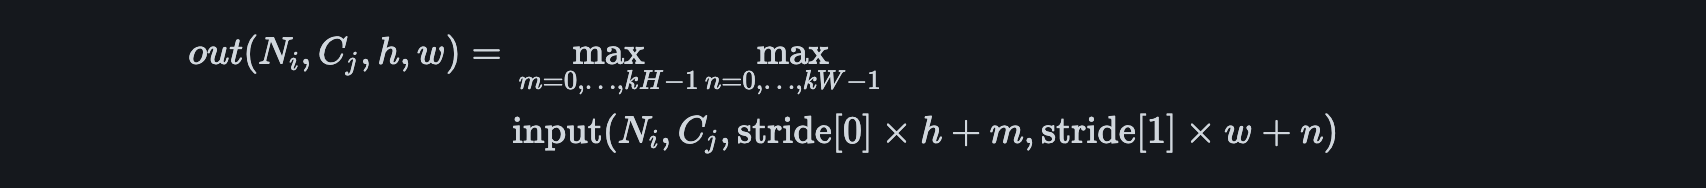

In [ ]:
def maxpool2d_forward(x: np.ndarray, k: int, stride: int = None):
    """x: (H, W) -> (out, argmax), out: (H_out, W_out),
    argmax: (H_out, W_out, 2) — координаты максимума в x для каждого окна"""
    if stride is None:
      stride = k
    H, W = x.shape
    Ho = (H - k) // stride +1
    Wo = (W - k) // stride + 1

    y= np.zeros((Ho, Wo))
    argmax = np.zeros((Ho, Wo, 2), dtype=int)
    for i in range(Ho):
      for j in range(Wo):
        window = x[i * stride:i*stride + k, j * stride:j*stride + k]
        idx = np.unravel_index(np.argmax(window), window.shape)
        y[i,j] = window[idx]
        argmax[i,j] = (i*stride + idx[0], j * stride + idx[1])
    return y, argmax



def maxpool2d_backward(dout: np.ndarray, argmax: np.ndarray, x_shape) -> np.ndarray:
    """dout: (H_out, W_out), argmax как из forward -> dx: x_shape"""
    dx = np.zeros(x_shape)
    Ho, Wo = dout.shape
    for i in range(Ho):
      for j in range(Wo):
        r,c = argmax[i,j]
        dx[r,c] += dout[i,j]
    return dx





In [ ]:
# self-check 2.5: forward сверяем с nn.functional.max_pool2d, backward — с его автогредом
xp = rng.standard_normal((6, 6))
out, amax = maxpool2d_forward(xp, 2, 2)
assert out.shape == (3, 3), f"неверная форма выхода: {out.shape}"

xp_t = torch.from_numpy(xp).double().requires_grad_(True)
out_ref = F.max_pool2d(xp_t[None, None], kernel_size=2, stride=2)[0, 0]
assert np.allclose(out, out_ref.detach().numpy(), atol=1e-6), "forward не совпадает с F.max_pool2d"

dout = rng.standard_normal(out.shape)
dx = maxpool2d_backward(dout, amax, xp.shape)

dout_t = torch.from_numpy(dout).double()
(out_ref * dout_t).sum().backward()
dx_ref = xp_t.grad.numpy()

assert np.allclose(dx, dx_ref, atol=1e-6), "backward не совпадает с градиентом torch.autograd"
print("OK: 2.5")


OK: 2.5


## Задача 2.6. Собираем всё вместе: подменяем `nn.Conv2d` своей реализацией

Возьмите настоящий `nn.Conv2d(in_channels=3, out_channels=5, kernel_size=3, stride=2, padding=1)` со случайными весами (как его создаёт PyTorch по умолчанию) и настоящую картинку (можно случайный тензор `(3, 16, 16)`).

Прогоните её через сам слой (`layer(x)`) и через свою `conv2d_general`, подставив туда `layer.weight` и `layer.bias`, переведённые в numpy. Результаты должны совпасть с точностью до `float32`.

In [ ]:
layer = torch.nn.Conv2d(in_channels=3, out_channels=5, kernel_size=3, stride=2, padding=1)
x_layer = torch.randn(3, 16, 16)

with torch.no_grad():
    y_layer = layer(x_layer[None])[0].numpy()

y_own = conv2d_general(
    x_layer.numpy(),
    layer.weight.detach().numpy(),
    layer.bias.detach().numpy(),
    stride=2, padding=1,
)

y_own_id2col = conv2d_im2col(
    x_layer.numpy(),
    layer.weight.detach().numpy(),
    layer.bias.detach().numpy(),
    stride=2, padding=1,
)

assert y_own.shape == y_layer.shape, f"форма не совпадает: {y_own.shape} vs {y_layer.shape}"
assert y_own_id2col.shape == y_layer.shape, f"форма не совпадает: {y_own_id2col.shape} vs {y_layer.shape}"
assert np.allclose(y_own, y_layer, atol=1e-4), "значения не совпадают с настоящим nn.Conv2d"
assert np.allclose(y_own_id2col, y_layer, atol=1e-4), "значения не совпадают с настоящим nn.Conv2d"
print("OK: 2.6 — своя реализация воспроизводит nn.Conv2d")

OK: 2.6 — своя реализация воспроизводит nn.Conv2d


---
# Часть 3

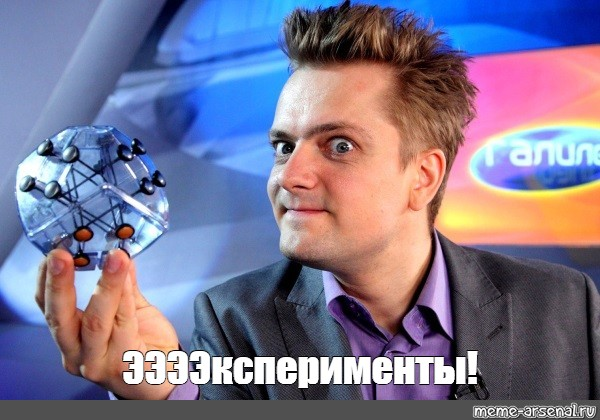


## Задача 3.1. Свёртка без единого явного цикла

Реализуйте `conv2d_general` из 2.2 (многоканальный вход, stride, но без паддинга — паддинг можно сделать `np.pad` перед вызовом) без единого `for`/`while` — только `sliding_window_view`.

Для самых умных котят - можно использовать `einsum` (или `tensordot`)


In [ ]:
def conv2d_no_loops(x: np.ndarray, w: np.ndarray, b: np.ndarray = None, stride: int = 1) -> np.ndarray:
    """x: (C_in, H, W) уже с нужным паддингом, w: (C_out, C_in, kh, kw) -> y: (C_out, H_out, W_out)"""
    # TODO: ваш код, без циклов
    raise NotImplementedError


In [ ]:
# self-check 3.1
for stride, padding in [(1, 0), (2, 1)]:
    x_padded = np.pad(x_test, ((0, 0), (padding, padding), (padding, padding))) if padding else x_test
    y_nl = conv2d_no_loops(x_padded, w_test, b_test, stride=stride)
    y_ref = conv2d_general(x_test, w_test, b_test, stride=stride, padding=padding)
    assert np.allclose(y_nl, y_ref), f"stride={stride}, padding={padding}: не совпадает"
print("OK: 3.1")


## Задача 3.2. Свёртка как умножение на матрицу

Постройте явную матрицу $T$ размера $(H_{out}\cdot W_{out}) \times (H\cdot W)$ такую, что

$$\text{conv}(x, w).\text{flatten}() = T \cdot x.\text{flatten}()$$

для одноканальной свёртки без паддинга, stride 1.




In [ ]:
def conv_matrix_1ch(H: int, W: int, w: np.ndarray):
    """w: (kh, kw) -> (T, (H_out, W_out)), T: (H_out*W_out, H*W)"""
    # TODO: ваш код
    raise NotImplementedError


In [ ]:
# self-check 3.2
x2 = rng.standard_normal((5, 5))
w2 = rng.standard_normal((3, 3))
T, (Ho, Wo) = conv_matrix_1ch(5, 5, w2)
assert T.shape == (Ho * Wo, 25), f"неверная форма матрицы: {T.shape}"

y_mat = (T @ x2.flatten()).reshape(Ho, Wo)
y_ref = conv2d_naive_1ch(x2, w2)
assert np.allclose(y_mat, y_ref), "умножение на матрицу не совпадает со свёрткой"
print("OK: 3.2, T.shape =", T.shape, f"(при этом всего {np.count_nonzero(T)} ненулевых элементов из {T.size})")


## Задача 3.3 (бонус). Свёртка через FFT

Теорема о свёртке: свёртка в пространственной области — это поэлементное умножение в частотной. Реализуйте одноканальную свёртку (без паддинга, stride 1) через `np.fft.rfft2`/`irfft2` и сравните по скорости с наивной версией при большом ядре.

Подсказка: FFT считает **полную** циклическую свёртку с развёрнутым (`[::-1, ::-1]`) ядром — из неё нужно вырезать кусок, соответствующий `valid`-области без разворота.


In [ ]:
def conv2d_fft(x: np.ndarray, w: np.ndarray) -> np.ndarray:
    """x: (H, W), w: (kh, kw) -> y: (H-kh+1, W-kw+1), через FFT"""
    # TODO: ваш код
    raise NotImplementedError


In [ ]:
# self-check 3.3
x3 = rng.standard_normal((40, 40))
w3 = rng.standard_normal((9, 9))

y_fft = conv2d_fft(x3, w3)
y_ref = conv2d_naive_1ch(x3, w3)
assert np.allclose(y_fft, y_ref, atol=1e-8), "FFT-свёртка не совпадает с наивной"
print("OK: 3.3")

import time
t0 = time.perf_counter(); conv2d_naive_1ch(x3, w3); t1 = time.perf_counter()
conv2d_fft(x3, w3); t2 = time.perf_counter()
print(f"наивная: {t1-t0:.5f}s, FFT: {t2-t1:.5f}s (ядро {w3.shape}, разница растёт с размером ядра)")
